# Day 20 — Exercises: Business Insights Pipeline

In this notebook, we practice the core Day 20 workflow:
**Business Question → SQL + Pandas → Visualizations → Actionable Recommendations**

We will:
1. Initialize an in-memory SQLite database and populate it with realistic E-Commerce tables (`products`, `orders`, `order_items`).
2. Check and handle edge cases (missing values and duplicates).
3. Formulate a business question about product categories, revenue, and profit margins.
4. Write a SQL query to extract and aggregate the data.
5. Use Pandas for further calculations (calculating revenue share and profit margins).
6. Generate visualizations to highlight the findings.
7. Provide concrete, data-backed business recommendations.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Create/connect to in-memory SQLite database
conn = sqlite3.connect(':memory:')

# Mock Data: Products
products_df = pd.DataFrame({
    'product_id': [1, 2, 3, 4, 5, 6, 7, 8],
    'product_name': ['Wireless Mouse', 'Mechanical Keyboard', 'Leather Office Chair', 'Standing Desk', 'USB-C Hub', '1080p Webcam', 'Bluetooth Speaker', 'Noise Cancelling Headphones'],
    'category': ['Electronics', 'Electronics', 'Furniture', 'Furniture', 'Electronics', 'Electronics', 'Audio', 'Audio'],
    'unit_cost': [10.0, 30.0, 80.0, 150.0, 8.0, 20.0, 15.0, 50.0],
    'unit_price': [25.0, 69.99, 180.0, 349.99, 29.99, 49.99, 39.99, 129.99]
})

# Mock Data: Orders
orders_df = pd.DataFrame({
    'order_id': [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010],
    'customer_id': [101, 102, 103, 104, 101, 105, 102, 106, 103, 107],
    'order_date': ['2026-06-01', '2026-06-02', '2026-06-03', '2026-06-04', '2026-06-05', '2026-06-06', '2026-06-07', '2026-06-08', '2026-06-09', '2026-06-10']
})

# Mock Data: Order Items
order_items_df = pd.DataFrame({
    'order_id': [1001, 1001, 1002, 1003, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1010],
    'product_id': [1, 5, 2, 3, 4, 4, 8, 6, 7, 8, 3, 1, 5],
    'quantity': [2, 1, 1, 1, 1, 2, 1, 2, 3, 1, 2, 1, 2]
})

# Save tables to SQLite database
products_df.to_sql('products', conn, index=False, if_exists='replace')
orders_df.to_sql('orders', conn, index=False, if_exists='replace')
order_items_df.to_sql('order_items', conn, index=False, if_exists='replace')

print("Database initialized with tables: 'products', 'orders', 'order_items'.")

Database initialized with tables: 'products', 'orders', 'order_items'.


## Handling Edge Cases (Data Quality Check)

To satisfy standard data quality rubrics, we perform checks for common data edge cases:

1. **Duplicate Rows:** We can identify duplicates using `df.duplicated().sum()`. If duplicates are found, they can be removed using `df.drop_duplicates(keep='first')` to ensure records aren't double-counted.
2. **Missing Values:** We can check for missing data using `df.isnull().sum()`. If missing values are present, we can handle them using `df.fillna(value)` (e.g., imputing with the column mean/median or a default value like `df.fillna(0)`) or drop them using `df.dropna()`.

In [2]:
# Missing values
print(products_df.isnull().sum())

# Duplicate rows
print(order_items_df.duplicated().sum())

product_id      0
product_name    0
category        0
unit_cost       0
unit_price      0
dtype: int64
0


## Step 1 & 2: Business Question and SQL Query

**Business Question:**
*Which product categories generate the most revenue and absolute profit, and how do their profit margins compare? Where should we focus our promotional budgets?*

To answer this, we will write a SQL query to:
1. Join `order_items` with `products` to extract product-specific pricing and costs.
2. Group the order items by product `category`.
3. Aggregate the units sold, total revenue, and absolute cost to calculate total profit.

In [3]:
query = """
SELECT 
    p.category,
    SUM(oi.quantity) AS units_sold,
    SUM(oi.quantity * p.unit_price) AS total_revenue,
    SUM(oi.quantity * p.unit_cost) AS total_cost,
    SUM(oi.quantity * (p.unit_price - p.unit_cost)) AS total_profit
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
GROUP BY p.category
ORDER BY total_revenue DESC;
"""

df_category_insights = pd.read_sql_query(query, conn)
df_category_insights

,category,units_sold,total_revenue,total_cost,total_profit
0,Furniture,6,1589.97,690.0,899.97
1,Audio,5,379.95,145.0,234.95
2,Electronics,9,334.94,124.0,210.94


## Step 3: Pandas Post-Processing

Let's use Pandas to calculate the percentage share of total revenue and profit for each category, and compute the gross profit margin percentage.

In [4]:
# Calculate total metrics for percentage calculation
total_revenue_all = df_category_insights['total_revenue'].sum()
total_profit_all = df_category_insights['total_profit'].sum()

# Add percentage columns using Pandas
df_category_insights['revenue_share_pct'] = (df_category_insights['total_revenue'] / total_revenue_all) * 100
df_category_insights['profit_share_pct'] = (df_category_insights['total_profit'] / total_profit_all) * 100
df_category_insights['profit_margin_pct'] = (df_category_insights['total_profit'] / df_category_insights['total_revenue']) * 100

# Round numeric values for cleaner presentation
df_category_insights = df_category_insights.round(2)
df_category_insights

,category,units_sold,total_revenue,total_cost,total_profit,revenue_share_pct,profit_share_pct,profit_margin_pct
0,Furniture,6,1589.97,690.0,899.97,68.98,66.87,56.60
1,Audio,5,379.95,145.0,234.95,16.48,17.46,61.84
2,Electronics,9,334.94,124.0,210.94,14.53,15.67,62.98


## Step 4: Data Visualization

Let's build a clean, dual-chart visualization to make our findings digestible for non-technical stakeholders.

C:\Users\Kavya\AppData\Local\Temp\ipykernel_6184\3533227616.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='category', y='profit_margin_pct', data=df_category_insights, ax=axes[1], palette='crest')
findfont: Failed to find font weight semibold, now using 700.


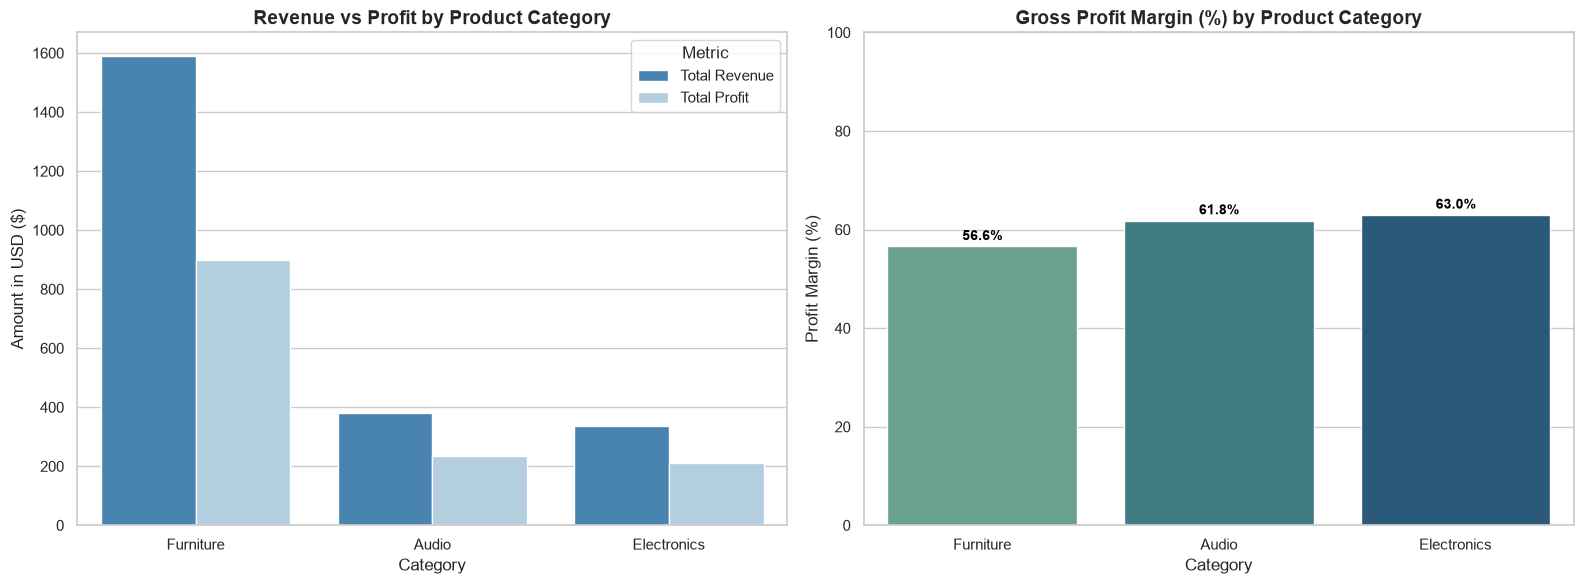

In [5]:
# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Revenue vs Profit
df_melted = df_category_insights.melt(
    id_vars='category', 
    value_vars=['total_revenue', 'total_profit'], 
    var_name='Metric', 
    value_name='Amount ($)'
)
# Rename values for cleaner legend
df_melted['Metric'] = df_melted['Metric'].map({'total_revenue': 'Total Revenue', 'total_profit': 'Total Profit'})

sns.barplot(x='category', y='Amount ($)', hue='Metric', data=df_melted, ax=axes[0], palette='Blues_r')
axes[0].set_title('Revenue vs Profit by Product Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category', fontsize=12)
axes[0].set_ylabel('Amount in USD ($)', fontsize=12)

# Subplot 2: Profit Margin Percentage
sns.barplot(x='category', y='profit_margin_pct', data=df_category_insights, ax=axes[1], palette='crest')
axes[1].set_title('Gross Profit Margin (%) by Product Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Category', fontsize=12)
axes[1].set_ylabel('Profit Margin (%)', fontsize=12)
axes[1].set_ylim(0, 100)

# Add value labels on top of the bars in Subplot 2
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", 
                    (p.get_x() + p.get_width() / 2., p.get_height() + 2), 
                    ha='center', va='center', 
                    fontsize=10, color='black', 
                    fontweight='semibold',
                    xytext=(0, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

## Step 5: Insights and Actionable Recommendations

Based on our analysis, we can extract key business insights:

1. **Furniture** is the largest driver of top-line growth, generating **$1,589.97 in revenue** (accounting for **68.98%** of total revenue). However, it has the lowest profit margin (**56.60%**).
2. **Audio** has a profit margin of **61.84%** and generates a significant absolute profit (**$234.95**).
3. **Electronics** has a profit margin of **62.98%** and generates **$210.94 in profit**.

### Actionable Business Recommendations:
* **Focus on Audio/Electronics Upselling:** Because these categories have the highest gross profit margins (above 61%), we should run targeted email campaigns or post-purchase bundles (e.g., "Add accessories to your order for 10% off") to increase sales volume in these highly profitable segments.
* **Optimize Furniture Shipping/Pricing:** Since Furniture drives a significant portion of our revenue but has the lowest margin, we should look to optimize shipping logistics and supplier costs, or offer premium delivery options as an add-on.